In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

### Minimal Preprocessing for Both Datasets

In [2]:
# Datasets
df_customers = pd.read_csv("DM_AIAI_CustomerDB.csv")
df_flights = pd.read_csv("DM_AIAI_FlightsDB.csv")

# Replace empty entries with NaN
df_customers.replace("", np.nan, inplace=True)
df_flights.replace("", np.nan, inplace=True)

# Change values to datetime for easier manipulation
df_customers['EnrollmentDateOpening'] = pd.to_datetime(df_customers['EnrollmentDateOpening'], errors='coerce')
df_customers['CancellationDate'] = pd.to_datetime(df_customers['CancellationDate'], errors='coerce')
df_flights['YearMonthDate'] = pd.to_datetime(df_flights['YearMonthDate'], errors='coerce')

We are going to eliminate ID's that are associated to more than one person. These ID's are not always individual, they are refered to accounts that can be individual or collective. So we eliminate colective accounts. 

In [3]:
# Get ID's from colective accounts (more than one person)
bad_ids = (df_flights.duplicated(subset=["Loyalty#", "YearMonthDate"], keep=False))
bad_loyalty_ids = df_flights.loc[bad_ids, "Loyalty#"].unique()

# Eliminate those rows
df_flights = df_flights[~df_flights["Loyalty#"].isin(bad_loyalty_ids)]
df_customers = df_customers[~df_customers["Loyalty#"].isin(bad_loyalty_ids)]

**Deal with observations with `DistanceKM` > 0 and `NumFlights` = 0**

In [4]:
# lets see the rows where DistanceKM is > 0 and NumFlights == 0 
print(df_flights[(df_flights['DistanceKM'] > 0) & (df_flights['NumFlights'] == 0)].shape)

# Convert "NumFlights" entries into NaN
df_flights.loc[(df_flights['DistanceKM'] > 0) & (df_flights['NumFlights'] == 0), 'NumFlights'] = np.nan

(5823, 10)


**Deal with observations with `DistanceKM` per flight > 15,349**

In [5]:
mask_bad = (df_flights["NumFlights"] > 0) & (df_flights["DistanceKM"] / df_flights["NumFlights"] > 15349)
df_flights.loc[mask_bad, "NumFlights"] = np.nan

mask_bad.sum()

np.int64(10226)

In [6]:
df_flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [7]:
df_flights.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
YearMonthDate                   0
NumFlights                  16049
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
dtype: int64

**Impute `NumFlights` with Linear Regression** - KNN was taking too long

In [8]:
# Valid mask to aggregate observations for imputation
mask_valid = (df_flights["NumFlights"].notna() & df_flights["DistanceKM"].notna() & (df_flights["NumFlights"] > 0)
)
# Where we want to impute
mask_missing = df_flights["NumFlights"].isna()

# Just for sanity check - in the end we check if the imputation made sense
df_flights["NumFlights_imputed"] = False
df_flights.loc[mask_missing, "NumFlights_imputed"] = True

# Adjust model
X = df_flights.loc[mask_valid, ["DistanceKM"]]
y = df_flights.loc[mask_valid, "NumFlights"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Imputation
df_flights.loc[mask_missing, "NumFlights"] = (
    pd.Series(model.predict(df_flights.loc[mask_missing, ["DistanceKM"]]), index=df_flights.loc[mask_missing].index)
    .round()
    .clip(lower=0)
)

df_flights.loc[df_flights["NumFlights_imputed"]].head(20)


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,NumFlights_imputed
19,261109,2021,12,2021-12-01,6.0,0.0,13736.0,1373.0,0.0,0.0,True
41,377724,2021,12,2021-12-01,7.0,1.0,16998.0,1699.0,0.0,0.0,True
75,684835,2021,12,2021-12-01,9.0,1.0,22980.0,2298.0,4867.0,48.0,True
93,817609,2021,12,2021-12-01,10.0,0.0,23775.0,2377.0,0.0,0.0,True
96,192600,2021,12,2021-12-01,2.0,0.0,5119.0,511.0,0.0,0.0,True
112,366654,2021,12,2021-12-01,9.0,1.0,22839.0,2283.0,0.0,0.0,True
116,883242,2021,12,2021-12-01,8.0,0.0,20681.0,2068.0,0.0,0.0,True
126,755867,2021,12,2021-12-01,7.0,1.0,18236.0,1823.0,0.0,0.0,True
154,493800,2021,12,2021-12-01,7.0,0.0,17502.0,1750.0,0.0,0.0,True
177,607555,2021,12,2021-12-01,13.0,1.0,32056.0,3205.0,0.0,0.0,True


In [9]:
df_flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
NumFlights_imputed          0
dtype: int64

### Aggregate Data for Flights Dataset Using "Loyalty#"

In [10]:
# Create variable "Quarter" that assumes a value (1-4) according to the month 
df_flights['Quarter'] = df_flights['Month'].apply(lambda x: (x-1)//3 + 1)

# Study seasonality counting number of flights per quarter
df_seasonality = df_flights.groupby(['Loyalty#', 'Quarter'])['NumFlights'].sum().unstack(fill_value=0)
df_seasonality.columns = [f'Flights_Q{int(q)}' for q in df_seasonality.columns]
df_seasonality = df_seasonality.reset_index()

# Aggregate all data from the same "Loyalty#" number 
df_flights_agg = df_flights.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DollarCostPointsRedeemed': 'sum'
}).reset_index()

# Get the date from last flight per customer
df_last_flight = (df_flights[df_flights["NumFlights"] > 0].groupby("Loyalty#", as_index=False)["YearMonthDate"].max()
                  .rename(columns={"YearMonthDate": "LastFlightDate"}))

# Merge all datasets created into "df_all_flights"
df_flights_agg = df_flights_agg.merge(df_last_flight, on="Loyalty#", how="left")
df_all_flights = df_flights_agg.merge(df_seasonality, on="Loyalty#", how="left")

**Deal with observations with `PointsRedeemed` > `PointsAccumulated`**

In [11]:
df_all_flights = df_all_flights[df_all_flights["PointsRedeemed"] <= df_all_flights["PointsAccumulated"]] # they are removed

### Feature Engineering - Flights Dataset

In [12]:
# Get most recent date of the study for flights
recent_date = pd.to_datetime("2021-12-01")

# 1. Average Flight Distance 
df_all_flights["AvgFlightDistance"] = (df_all_flights["DistanceKM"] / df_all_flights["NumFlights"].replace(0, np.nan)).fillna(-1)

# 2. Companion Ratio 
df_all_flights["CompanionRatio"] = (df_all_flights["NumFlightsWithCompanions"] / df_all_flights["NumFlights"].replace(0, np.nan)).fillna(-1)

# 3. NoFlightsMonths -> number of months since the last flight
df_all_flights["NoFlightsMonths"] = ((recent_date - df_all_flights["LastFlightDate"]).dt.days // 30).fillna(-1)

# 5. Seasonality 
for q in [1, 2, 3, 4]:
    col_name = f'Flights_Q{q}'
    pct_name = f'%_Flights_Q{q}'
    # Get percentage of flights per quarter - it assumes values within [0,1]
    df_all_flights[pct_name] = np.where(df_all_flights["NumFlights"] > 0, df_all_flights[col_name] / df_all_flights["NumFlights"], 0)

### Feature Engineering - Customers Dataset

In [13]:
# Assume that "today" is the last recent date found in dataset
max_date = max(df_customers["EnrollmentDateOpening"].max(), df_customers["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}")

# Compute difference in days
df_customers["Days_sub"] = (df_customers["CancellationDate"].fillna(max_date) - df_customers["EnrollmentDateOpening"]).dt.days

# If negative value, assume there was a switch of dates 
df_customers["Days_sub"] = df_customers["Days_sub"].abs()

Most recent date extracted: 2021-12-30 00:00:00


### Merge Datasets

In [14]:
# Merge datasets that have the same "Loyalty#" entries
df_final = df_all_flights.merge(df_customers, how="inner")

# Remove this columns since they don't give any useful information that the others already give
df_final = df_final.drop(columns = ['Loyalty#', 'Flights_Q1', 'Flights_Q2', 'Flights_Q3', 'Flights_Q4','LastFlightDate', 'Unnamed: 0', 'First Name', 
                         'Last Name', 'Customer Name', 'Country', 'Latitude', 'Longitude', 'Postal code', 'Location Code', 
                         'EnrollmentDateOpening', 'CancellationDate'])

df_final.columns

Index(['NumFlights', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'NumFlightsWithCompanions', 'DollarCostPointsRedeemed',
       'AvgFlightDistance', 'CompanionRatio', 'NoFlightsMonths',
       '%_Flights_Q1', '%_Flights_Q2', '%_Flights_Q3', '%_Flights_Q4',
       'Province or State', 'City', 'Gender', 'Education', 'Income',
       'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub'],
      dtype='object')

In [15]:
df_final.isna().sum() # No missing values, nice

NumFlights                  0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
NumFlightsWithCompanions    0
DollarCostPointsRedeemed    0
AvgFlightDistance           0
CompanionRatio              0
NoFlightsMonths             0
%_Flights_Q1                0
%_Flights_Q2                0
%_Flights_Q3                0
%_Flights_Q4                0
Province or State           0
City                        0
Gender                      0
Education                   0
Income                      0
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value     0
EnrollmentType              0
Days_sub                    0
dtype: int64

### Outlier Detection - Isolation Forest

Outliers detetados: 162


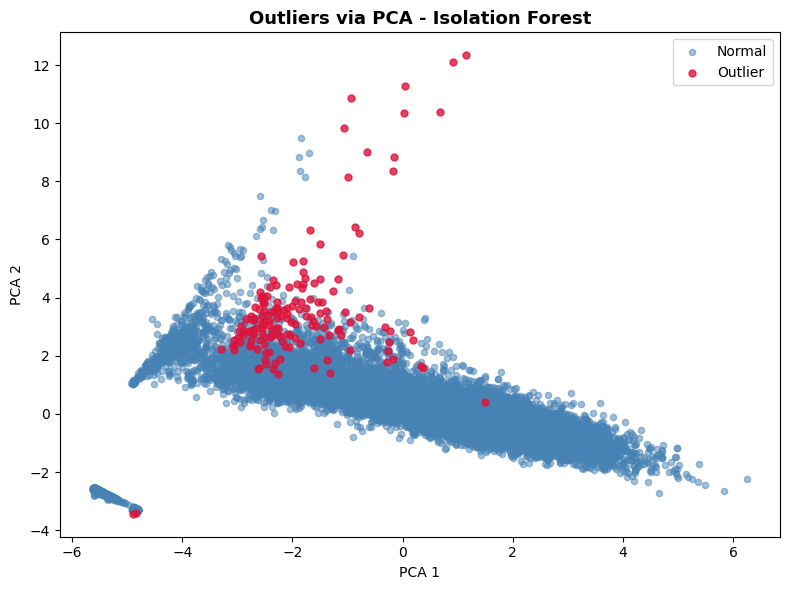

In [16]:
# Get numerical features (exclude the binary ones) for Isolation Forest 
variables_outliers = (df_final.select_dtypes(include="number").columns)

# Create dataset for outlier detection
df_IF = df_final[variables_outliers].copy()

# Standardize data
scaler = StandardScaler()
df_IF_scaled = pd.DataFrame(
    scaler.fit_transform(df_IF),
    columns=df_IF.columns,
    index=df_IF.index
)

# Apply Isolation Forest
iso = IsolationForest(contamination=0.01, random_state=42) 
outliers_pred = iso.fit_predict(df_IF_scaled)
df_IF_scaled["Outlier"] = outliers_pred

num_outliers = (df_IF_scaled["Outlier"] == -1).sum()
perc_outliers = num_outliers / len(df_IF_scaled) * 100
print(f"Outliers detetados: {num_outliers}")

# PCA with outliers
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_IF_scaled.drop(columns=["Outlier"]))


plt.figure(figsize=(8, 6))
plt.scatter(X_pca[df_IF_scaled["Outlier"] == 1, 0],
            X_pca[df_IF_scaled["Outlier"] == 1, 1],
            color="steelblue", alpha=0.5, s=20, label="Normal")


plt.scatter(X_pca[df_IF_scaled["Outlier"] == -1, 0],
            X_pca[df_IF_scaled["Outlier"] == -1, 1],
            color="crimson", alpha=0.8, s=25, label="Outlier")

plt.title("Outliers via PCA - Isolation Forest", fontsize=13, weight="bold")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(frameon=True)
plt.grid(False)
plt.tight_layout()
plt.show()

### Outlier Detection - KNN

KNN outliers detetados: 162


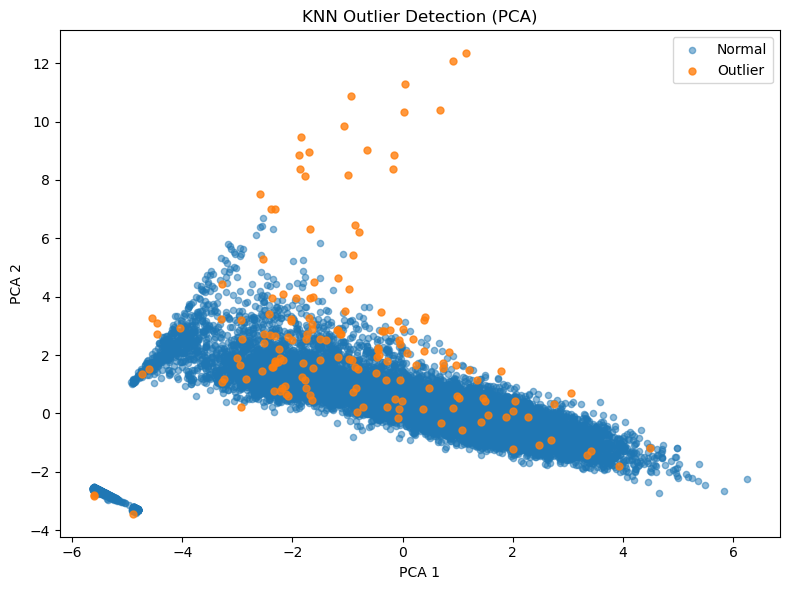

In [17]:
# Create dataset for outlier detection
df_KNN = df_final[variables_outliers].copy()

# Standardize data
scaler = StandardScaler()
df_KNN_scaled = scaler.fit_transform(df_KNN)

# Apply KNN 
k = 10
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(df_KNN_scaled)

distances, _ = nn.kneighbors(df_KNN_scaled)

knn_score = distances[:, 1:].mean(axis=1)
threshold = np.percentile(knn_score, 99)

df_KNN["Outlier_KNN"] = np.where(knn_score > threshold, -1, 1)

print(f"KNN outliers detetados: {(df_KNN['Outlier_KNN'] == -1).sum()}")

# PCA with outliers
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_KNN_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[df_KNN["Outlier_KNN"] == 1, 0],
    X_pca[df_KNN["Outlier_KNN"] == 1, 1],
    s=20, alpha=0.5, label="Normal"
)

plt.scatter(
    X_pca[df_KNN["Outlier_KNN"] == -1, 0],
    X_pca[df_KNN["Outlier_KNN"] == -1, 1],
    s=25, alpha=0.8, label="Outlier"
)

plt.title("KNN Outlier Detection (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.tight_layout()
plt.show()


In [18]:
df_final.columns

Index(['NumFlights', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'NumFlightsWithCompanions', 'DollarCostPointsRedeemed',
       'AvgFlightDistance', 'CompanionRatio', 'NoFlightsMonths',
       '%_Flights_Q1', '%_Flights_Q2', '%_Flights_Q3', '%_Flights_Q4',
       'Province or State', 'City', 'Gender', 'Education', 'Income',
       'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub'],
      dtype='object')

# Behaviour Based Perspective

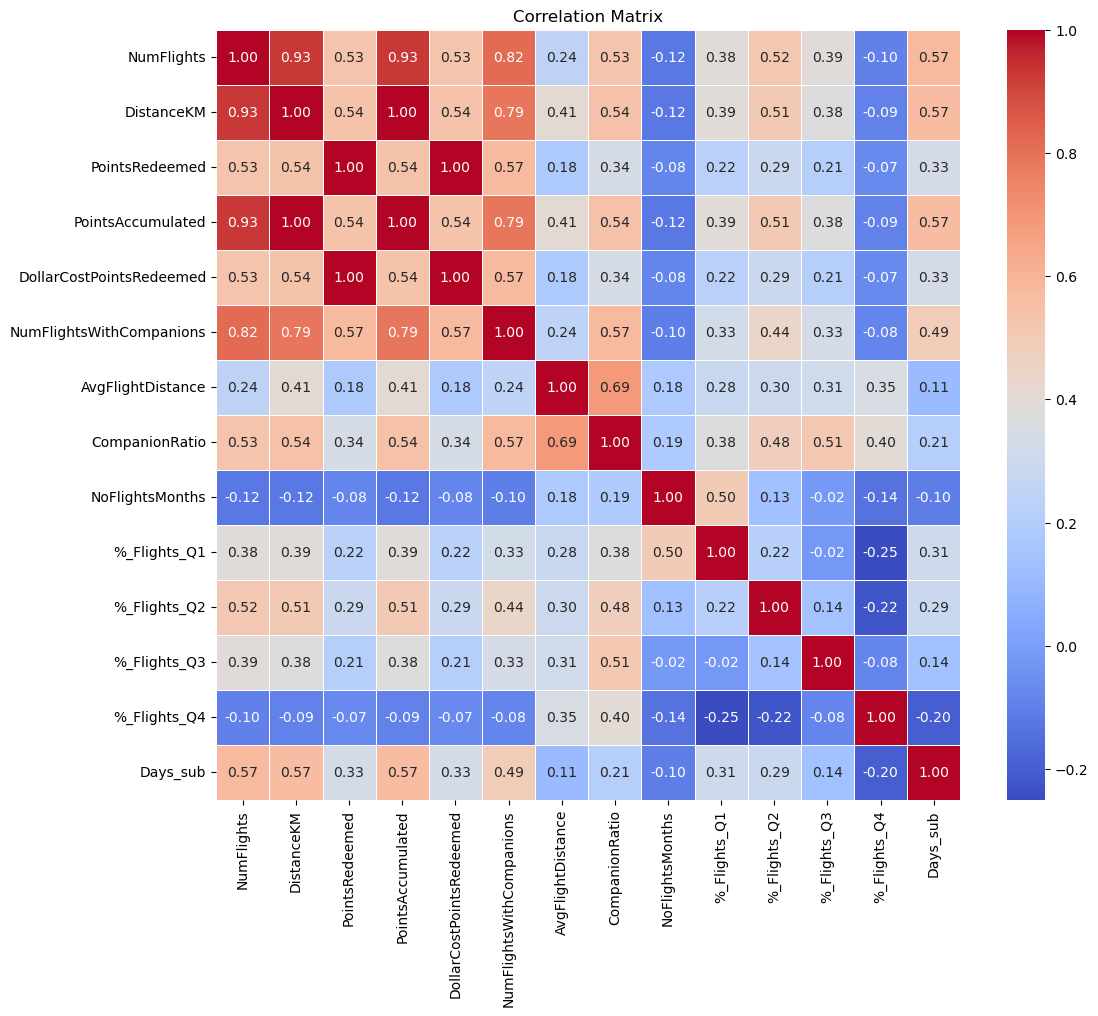

In [19]:
# Variables used to build behaviour perspective -> already chose them accordingly to the correlation coefficient between each one of themf
behaviour_columns = ['NumFlights', 'DistanceKM', 'PointsRedeemed', 'PointsAccumulated', 'DollarCostPointsRedeemed',
                     'NumFlightsWithCompanions', 'AvgFlightDistance', 'CompanionRatio', 'NoFlightsMonths',
                     '%_Flights_Q1', '%_Flights_Q2', '%_Flights_Q3', '%_Flights_Q4', 'Days_sub']

# Calculate correlation matrix
corr_matrix = df_final[behaviour_columns].corr()

# Criar o heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### Data visualization - PCA

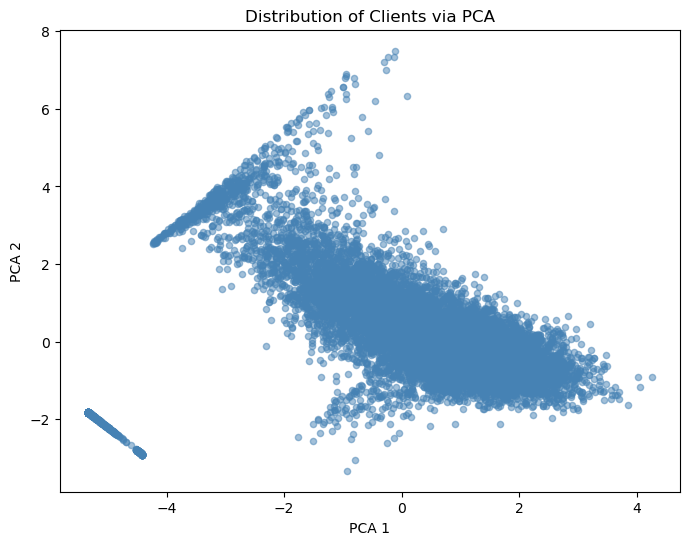

Variance: 53.76%


In [20]:
# Removed columns with high colinearity ("NumFlights", "PoinstAccumulated", "DollarCostPointsRedeemed")
behaviour_columns = ['DistanceKM', 'PointsRedeemed','NumFlightsWithCompanions', 'AvgFlightDistance', 
                     'CompanionRatio', 'NoFlightsMonths', '%_Flights_Q1', '%_Flights_Q2', '%_Flights_Q3', '%_Flights_Q4', 'Days_sub']

# Remove outliers
df_final_cleaned = df_final[df_KNN["Outlier_KNN"] == 1].copy()
df_final_cleaned = df_final_cleaned[behaviour_columns]

# Scaling
scaler = StandardScaler()
df_final_cleaned_scaled = scaler.fit_transform(df_final_cleaned)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_final_cleaned_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            color="steelblue", alpha=0.5, s=20)
plt.title("Distribution of Clients via PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

print(f"Variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

## K-Means++

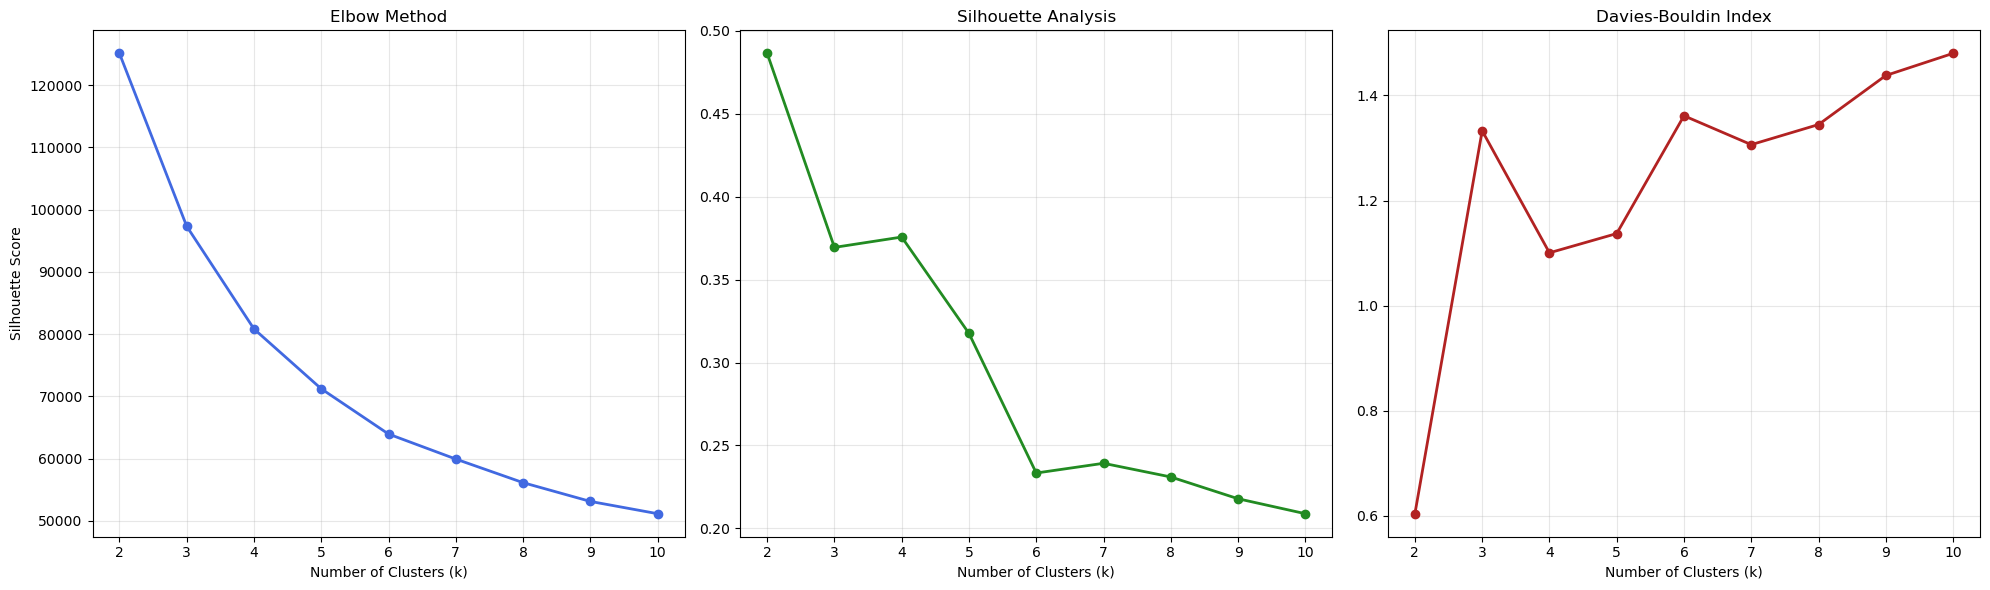

In [21]:
def get_number_clusters(df, outlier_labels, features, k_range=range(2, 11)):

    # Remove outliers from original merged dataset  
    df_clean = df[outlier_labels == 1].copy()
    X = df_clean[features]
    
    # Data Scaling 
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    # Get metrics: WSS for Elbow Method, Silhouette Analysis and Davies-Bouldin Index
    wss = []
    silhouette_scores = []
    db_indices = []

    # Iterate over number of clusters (2-10)
    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = kmeans.fit_predict(X_scaled)
        
        wss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        db_indices.append(davies_bouldin_score(X_scaled, labels))
    

    # Get the 3 plots
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))
    
    # WSS - Elbow Method
    ax[0].plot(k_range, wss, marker='o', color='royalblue', linewidth=2)
    ax[0].set_title('Elbow Method', fontsize=12)
    ax[0].set_xlabel('Number of Clusters (k)')
    ax[0].set_ylabel('WSS')
    ax[0].grid(True, alpha=0.3)
    
    # Silhouette Analysis
    ax[1].plot(k_range, silhouette_scores, marker='o', color='forestgreen', linewidth=2)
    ax[1].set_title('Silhouette Analysis', fontsize=12)
    ax[1].set_xlabel('Number of Clusters (k)')
    ax[0].set_ylabel('Silhouette Score')
    ax[1].grid(True, alpha=0.3)
    
    # Davies-Bouldin Index
    ax[2].plot(k_range, db_indices, marker='o', color='firebrick', linewidth=2)
    ax[2].set_title('Davies-Bouldin Index', fontsize=12)
    ax[2].set_xlabel('Number of Clusters (k)')
    ax[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return X_scaled, df_clean


df_KMeans_scaled, df_final_clean = get_number_clusters(df_final, df_KNN["Outlier_KNN"], behaviour_columns)

### Cluster Visualization - PCA

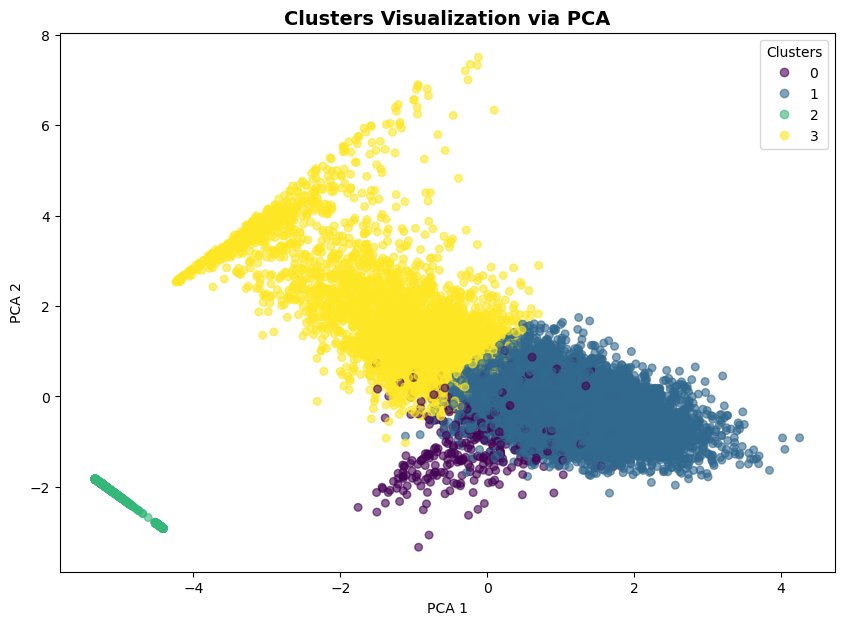

In [27]:
# Get clusters assuming k = 4 is the best one
k_final = 4
kmeans = KMeans(n_clusters=k_final, init='k-means++', n_init=10, random_state=42)
clusterKMeans_labels = kmeans.fit_predict(df_KMeans_scaled)

# PCA Visualization
pca_visual = PCA(n_components=2)
X_pca = pca_visual.fit_transform(df_KMeans_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusterKMeans_labels, cmap='viridis', s=30, alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Clusters", loc="upper right")
plt.title(f"Clusters Visualization via PCA", fontsize=14, weight='bold')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(False)
plt.show()

## DBSCAN

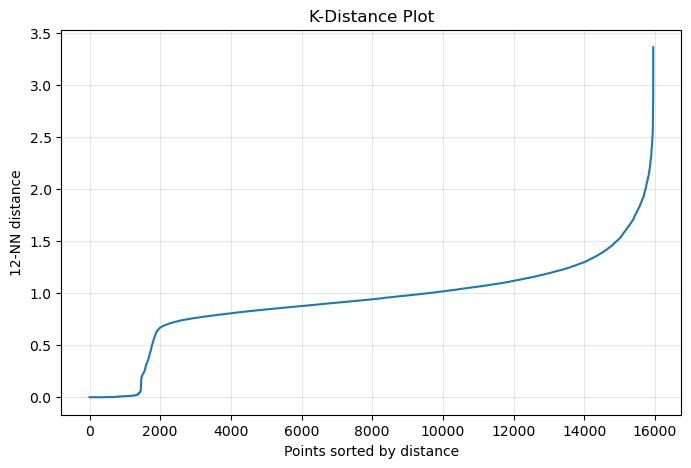

In [23]:
def get_epsilon_DBSCAN(df, outlier_labels, features):
    
    # Remove outliers from original merged dataset 
    df_clean = df[outlier_labels == 1].copy()
    X = df_clean[features]
    
    # Data Scaling 
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    # Find appropriate epsilon 
    min_samples = len(behaviour_columns) + 1 # Since it needs to be greater or equal to dim(features) + 1
    
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    
    # Get a k-distance plot
    dist_ordenada = np.sort(distances[:, min_samples-1], axis=0)
    
    plt.figure(figsize=(8, 5))
    plt.plot(dist_ordenada)
    plt.title(f'K-Distance Plot')
    plt.xlabel('Points sorted by distance')
    plt.ylabel(f'{min_samples}-NN distance')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return X_scaled, df_clean, min_samples

df_DBSCAN_scaled, df_final_clean, min_pts = get_epsilon_DBSCAN(df_final, df_KNN["Outlier_KNN"], behaviour_columns)

C:\Users\anton\AppData\Local\Temp\ipykernel_12296\911268065.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("viridis", len(unique_labels))


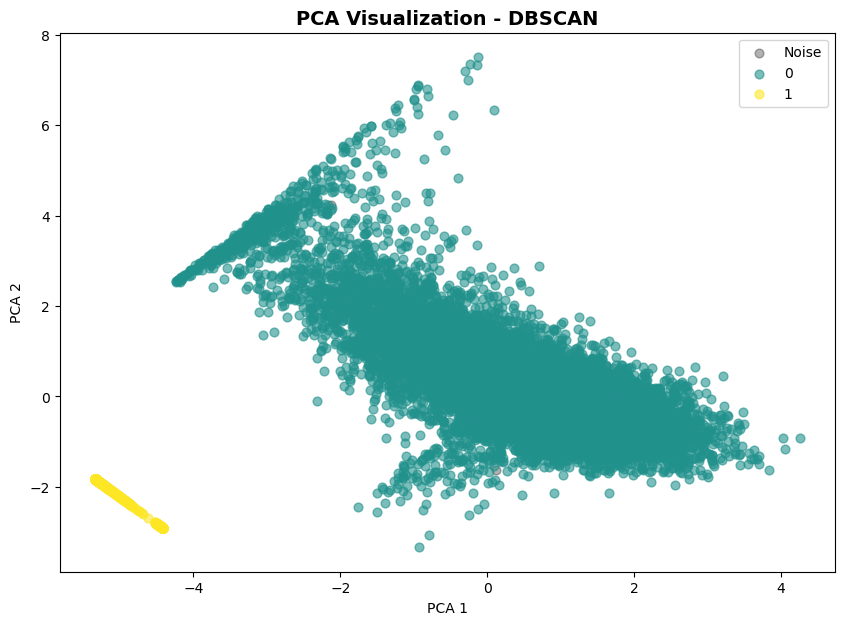

Noise values: 19 (0.12%)


In [24]:
eps_escolhido = 2 # I choose 2.0, it's not certain
dbscan = DBSCAN(eps=eps_escolhido, min_samples=min_pts)
labels_db = dbscan.fit_predict(df_DBSCAN_scaled)

# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_DBSCAN_scaled)

plt.figure(figsize=(10, 7))
unique_labels = sorted(set(labels_db)) # get labels
colors = plt.cm.get_cmap("viridis", len(unique_labels))

for i, label in enumerate(unique_labels):
    mask = (labels_db == label)
    
    # To identificate noise values (we removed outliers but there are definitely noise values)
    if label == -1:
        color = 'black'
        label_name = 'Noise'
        alpha = 0.3
        marker = 'o' 
    else:
        color = colors(i)
        label_name = f'{label}'
        alpha = 0.6
        marker = 'o'

    plt.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        c=[color], 
        label=label_name, 
        alpha=alpha, 
        s=40,
        marker=marker
    )

plt.title(f"PCA Visualization - DBSCAN", fontsize=14, weight='bold')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(loc='best', frameon=True)
plt.grid(False)
plt.show()

n_noise = list(labels_db).count(-1)
print(f"Noise values: {n_noise} ({n_noise/len(df_DBSCAN_scaled)*100:.2f}%)")

### Median values for each behaviour variable per cluster - KMeans

Comparing both algorithms, accordingly to the number of clusters created and our goal to create economical strategies to deal with our customers, we chose KMeans wuth k = 4 clusters

In [25]:
# Add the cluster labels in the clean merged dataset
df_final_clean['Cluster_KMeans'] = clusterKMeans_labels

# Calculate the median values for each behaviour variable
profile_clustersKMeans = df_final_clean.groupby('Cluster_KMeans')[behaviour_columns].mean()
profile_clustersKMeans['Count'] = df_final_clean.groupby('Cluster_KMeans').size() # get the number of clients per cluster

display(profile_clustersKMeans.T)

Cluster_KMeans,0,1,2,3
DistanceKM,145485.872026,389429.211341,0.775733,135612.975599
PointsRedeemed,3057.880617,11416.483984,0.000000,2871.101804
NumFlightsWithCompanions,17.864317,48.335627,0.000000,15.339574
AvgFlightDistance,1911.986051,1965.441866,-1.000000,2047.470916
CompanionRatio,0.232436,0.243176,-1.000000,0.232107
NoFlightsMonths,16.544053,0.526662,-1.000000,0.857143
%_Flights_Q1,0.494797,0.207514,0.000000,0.075251
%_Flights_Q2,0.278617,0.264844,0.000000,0.155971
%_Flights_Q3,0.172713,0.291897,0.000000,0.291628
%_Flights_Q4,0.053873,0.235745,0.000000,0.477150
